# Kámárí · Data Pipeline v2  (single notebook · Google Colab)

This v2 notebook keeps the original one-notebook structure:

1. **Gather** every dataset named in the recommendations, where access/licence permits.
2. **Preprocess** faces into the canonical manifest/crop structure.
3. **EDA** with African-domain, Black-subset, dark-skin, and 13–21 boundary checks.
4. **Publish** private/licence-safe Hugging Face artifacts for Modal training and benchmark handoff.

Colab is the target runtime. Request-only/agreement datasets cannot be downloaded without approved access; the notebook records those as explicit missing-access items instead of silently ignoring them. Raw/cropped faces are only uploaded to private HF repos when licence/consent allows redistribution.

In [1]:
# --- Kámárí bootstrap: Colab first, local fallback ---
import os, sys, pathlib, subprocess

IN_COLAB = 'google.colab' in sys.modules
SECRET_KEYS = [
    'KAMARI_REPO_URL', 'KAMARI_REPO_PATH', 'HF_TOKEN', 'HF_NAMESPACE',
    'KAGGLE_USERNAME', 'KAGGLE_KEY', 'PUBLISH_TO_HF', 'KAMARI_DOWNLOAD_LARGE',
    'ADIENCE_KAGGLEHUB_SLUG', 'AGEDB_KAGGLEHUB_SLUG', 'FAGE_KAGGLEHUB_SLUG',
    'AXONDATA_KAGGLEHUB_SLUG', 'LFW_KAGGLEHUB_SLUG', 'AGEDB30_KAGGLEHUB_SLUG',
    'FAGE_HF_REPO', 'AXONDATA_HF_REPO', 'AAF_HF_REPO', 'AGEDB_HF_REPO',
    'RFW_HF_REPO', 'BFW_HF_REPO', 'CELEBA_SPOOF_HF_REPO',
    'FAIRFACE_URL', 'APPA_REAL_URL', 'ADIENCE_URL', 'AGEDB_URL', 'FGNET_URL',
    'AAF_URL', 'AXONDATA_URL', 'LFW_URL', 'RFW_URL', 'BFW_URL',
    'CELEBA_SPOOF_URL', 'CEFA_URL', 'OULU_NPU_URL', 'CASIA_FACE_AFRICA_URL',
    'BVC_UNN_URL', 'NEFI_URL', 'ALLOW_PRIVATE_CROP_UPLOAD'
]

if IN_COLAB:
    try:
        from google.colab import userdata
        for key in SECRET_KEYS:
            try:
                value = userdata.get(key)
                if value not in (None, ''):
                    os.environ.setdefault(key, str(value))
            except Exception:
                pass
    except Exception:
        pass

    repo_path = pathlib.Path(os.environ.get('KAMARI_REPO_PATH', '/content/kamari'))
    if not (repo_path / 'data' / 'registry').exists():
        repo_url = os.environ.get('KAMARI_REPO_URL', '').strip()
        if not repo_url:
            raise RuntimeError('Set Colab secret KAMARI_REPO_URL to your GitHub repo before running this notebook.')
        subprocess.run(['git', 'clone', repo_url, str(repo_path)], check=True)
    REPO = repo_path
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', '-r', str(REPO / 'requirements-data.txt')], check=True)
else:
    REPO = next(
        (c for c in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
         if (c / 'data' / 'registry').exists()),
        pathlib.Path.cwd(),
    )
    try:
        from dotenv import load_dotenv
        load_dotenv(REPO / '.env')
    except Exception:
        pass

sys.path.insert(0, str(REPO))
print('REPO =', REPO, '| Colab:', IN_COLAB)

REPO = /content/kamari | Colab: True


In [2]:
import csv, json, math, os, re, shutil, tarfile, tempfile, urllib.request, zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import yaml
from PIL import Image
from tqdm.auto import tqdm
from concurrent.futures import ThreadPoolExecutor

from data import face_utils as F
from data.hf_utils import HF, dataset_card
from data.manifest_schema import MANIFEST_COLUMNS, empty_manifest, ita_to_band, make_row, sha256_bytes, validate

DATA_ROOT = Path(os.environ.get('KAMARI_DATA_ROOT', REPO / 'data'))
if not DATA_ROOT.is_absolute():
    DATA_ROOT = REPO / DATA_ROOT
RAW = DATA_ROOT / 'raw'
ARCHIVES = DATA_ROOT / 'archives'
CROPS = DATA_ROOT / 'processed' / 'crops_224'
MAN = DATA_ROOT / 'manifests'
BENCH_SPLITS = DATA_ROOT / 'benchmark' / 'age_gate_v0'
CARDS = DATA_ROOT / 'cards'
FIG = CARDS / 'eda'
for p in (RAW, ARCHIVES, CROPS, MAN, BENCH_SPLITS, CARDS, FIG):
    p.mkdir(parents=True, exist_ok=True)


def env_bool(name, default=False):
    value = os.environ.get(name)
    if value is None:
        return default
    return str(value).strip().lower() in {'1', 'true', 'yes', 'y', 'on'}

# ============================================================================
# RUN SETTINGS  --  edit these directly (these win over any Colab secret/env)
# ============================================================================
PUBLISH_TO_HF = True              # push datasets/manifests/cards to Hugging Face
ALLOW_PRIVATE_CROP_UPLOAD = True  # upload ALL crops to the PRIVATE kamari-faces-v0
                                  #   (required so Modal CNN training has images)
PREPROCESS_WORKERS = min(48, (os.cpu_count() or 8) * 2)  # auto: oversubscribe cores (I/O-bound)
DOWNLOAD_WORKERS = min(8, (os.cpu_count() or 8))         # auto: parallel dataset downloads
DETECT_BATCH = 64                 # large GPU face-detection batch (raise to 128 on big GPUs)
DETECT_SIZE = 320                 # square size images are resized to for detection
SKIP_DETECT_FOR_ALIGNED = True    # center-crop already-aligned sets (UTKFace/FairFace/AgeDB) -> no MTCNN
PACK_CROPS = True                 # upload crops as ONE tar (fast; scales past 100k files)
DOWNLOAD_LARGE = True             # fetch large sets (e.g. IMDB-WIKI); False to skip
QUALITY_MIN = 0.30                # drop crops below this face-quality
MAX_ROWS_PER_DATASET = 0          # 0 = no cap; set e.g. 500 for a fast test run
# ============================================================================

have_kaggle = bool(os.environ.get('KAGGLE_USERNAME') and os.environ.get('KAGGLE_KEY'))
hf = HF() if os.environ.get('HF_TOKEN') else None
registry = yaml.safe_load(open(REPO / 'data' / 'registry' / 'datasets_free_open.yaml'))

RECOMMENDED_DATASETS = [
    'UTKFace', 'FairFace', 'APPA-REAL', 'Adience', 'AgeDB', 'FG-NET', 'All-Age-Faces',
    'IMDB-WIKI', 'FAGE_v2', 'AxonData-10-30', 'LFW', 'RFW', 'BFW', 'AgeDB-30',
    'CelebA-Spoof', 'CeFA/CASIA-SURF-CeFA', 'OULU-NPU', 'CASIA-Face-Africa', 'BVC-UNN', 'NEFI'
]
AFRICAN_DATASETS = {'FAGE_v2', 'CASIA-Face-Africa', 'BVC-UNN', 'NEFI'}
AFRICAN_COUNTRIES = {
    'DZ','AO','BJ','BW','BF','BI','CM','CV','CF','TD','KM','CG','CD','CI','DJ','EG','GQ','ER','SZ',
    'ET','GA','GM','GH','GN','GW','KE','LS','LR','LY','MG','MW','ML','MR','MU','MA','MZ','NA','NE',
    'NG','RW','ST','SN','SC','ZA','SS','SD','TZ','TG','TN','UG','ZM','ZW'
}

DATASET_PLAN = [
    {'key': 'utkface', 'name': 'UTKFace', 'role': 'train', 'access': 'kaggle', 'kind': 'kaggle', 'slug': 'jangedoo/utkface-new', 'source_url': 'https://www.kaggle.com/datasets/jangedoo/utkface-new', 'adapter': 'utkface'},
    {'key': 'fairface', 'name': 'FairFace', 'role': 'benchmark', 'access': 'open_download', 'kind': 'url', 'env_url': 'FAIRFACE_URL', 'url': 'https://drive.google.com/uc?export=download&id=1Z1RqRo0_JiavaZw2yzZG6WETdZQ8qX86', 'archive': 'fairface-img-margin025-trainval.zip', 'source_url': 'https://github.com/joojs/fairface', 'extra_urls': [
        {'url': 'https://drive.google.com/uc?export=download&id=1i1L3Yqwaio7YSOCj7ftgk8ZZchPG7dmH', 'archive': 'fairface_label_train.csv'},
        {'url': 'https://drive.google.com/uc?export=download&id=1wOdja-ezstMEp81tX1a-EYkFebev4h7D', 'archive': 'fairface_label_val.csv'},
    ], 'adapter': 'fairface'},
    {'key': 'appa_real', 'name': 'APPA-REAL', 'role': 'train', 'access': 'open_download', 'kind': 'url', 'env_url': 'APPA_REAL_URL', 'url': 'https://data.chalearnlap.cvc.uab.cat/AppaRealAge/appa-real-release.zip', 'archive': 'appa-real-release.zip', 'source_url': 'https://chalearnlap.cvc.uab.cat/dataset/26/description/', 'adapter': 'appa_real'},
    {'key': 'adience', 'name': 'Adience', 'role': 'auxiliary', 'access': 'kagglehub', 'kind': 'kagglehub_or_url', 'env_slug': 'ADIENCE_KAGGLEHUB_SLUG', 'slug': 'alfredhhw/adiencegender', 'env_url': 'ADIENCE_URL', 'source_url': 'https://www.kaggle.com/datasets/alfredhhw/adiencegender', 'adapter': 'adience'},
    {'key': 'agedb', 'name': 'AgeDB', 'role': 'train', 'access': 'kagglehub', 'kind': 'kagglehub_hf_or_url', 'env_slug': 'AGEDB_KAGGLEHUB_SLUG', 'slug': 'nitingandhi/agedb-database', 'env_hf': 'AGEDB_HF_REPO', 'env_url': 'AGEDB_URL', 'source_url': 'https://www.kaggle.com/datasets/nitingandhi/agedb-database', 'adapter': 'generic'},
    {'key': 'fgnet', 'name': 'FG-NET', 'role': 'train', 'access': 'open_download', 'kind': 'url', 'env_url': 'FGNET_URL', 'url': 'http://yanweifu.github.io/FG_NET_data/FGNET.zip', 'archive': 'FGNET.zip', 'source_url': 'https://yanweifu.github.io/FG_NET_data/', 'adapter': 'fgnet'},
    {'key': 'all_age_faces', 'name': 'All-Age-Faces', 'role': 'auxiliary', 'access': 'open_download', 'kind': 'hf_or_url', 'env_hf': 'AAF_HF_REPO', 'env_url': 'AAF_URL', 'url': 'https://www.dropbox.com/s/a0lj1ddd54ns8qy/All-Age-Faces%20Dataset.zip?dl=1', 'archive': 'all-age-faces.zip', 'source_url': 'https://github.com/JingchunCheng/All-Age-Faces-Dataset', 'adapter': 'generic'},
    {'key': 'imdb_wiki', 'name': 'IMDB-WIKI', 'role': 'auxiliary', 'access': 'open_download', 'kind': 'multi_url', 'large': True, 'source_url': 'https://data.vision.ee.ethz.ch/cvl/rrothe/imdb-wiki/', 'urls': ['https://data.vision.ee.ethz.ch/cvl/rrothe/imdb-wiki/static/wiki_crop.tar', 'https://data.vision.ee.ethz.ch/cvl/rrothe/imdb-wiki/static/imdb_crop.tar'], 'adapter': 'imdb_wiki'},
    {'key': 'fage_v2', 'name': 'FAGE_v2', 'role': 'train', 'access': 'kagglehub', 'kind': 'kagglehub_hf_or_url', 'env_slug': 'FAGE_KAGGLEHUB_SLUG', 'slug': 'ajewoleolaitan/fage-dataset', 'env_hf': 'FAGE_HF_REPO', 'source_url': 'https://www.kaggle.com/datasets/ajewoleolaitan/fage-dataset', 'adapter': 'generic'},
    {'key': 'axondata_10_30', 'name': 'AxonData-10-30', 'role': 'auxiliary', 'access': 'kagglehub_verify_terms', 'kind': 'kagglehub_hf_or_url', 'env_slug': 'AXONDATA_KAGGLEHUB_SLUG', 'slug': 'axondata/face-recognition-age-estimation-dataset', 'env_hf': 'AXONDATA_HF_REPO', 'env_url': 'AXONDATA_URL', 'source_url': 'https://www.kaggle.com/datasets/axondata/face-recognition-age-estimation-dataset', 'adapter': 'generic'},
    {'key': 'lfw', 'name': 'LFW', 'role': 'benchmark', 'access': 'kagglehub', 'kind': 'kagglehub_or_url', 'env_slug': 'LFW_KAGGLEHUB_SLUG', 'slug': 'jessicali9530/lfw-dataset', 'env_url': 'LFW_URL', 'url': 'http://vis-www.cs.umass.edu/lfw/lfw.tgz', 'archive': 'lfw.tgz', 'source_url': 'https://www.kaggle.com/datasets/jessicali9530/lfw-dataset', 'adapter': 'verification_only'},
    {'key': 'rfw', 'name': 'RFW', 'role': 'benchmark', 'access': 'request', 'kind': 'hf_or_url', 'env_hf': 'RFW_HF_REPO', 'env_url': 'RFW_URL', 'source_url': 'http://www.whdeng.cn/RFW/index.html', 'adapter': 'verification_only'},
    {'key': 'bfw', 'name': 'BFW', 'role': 'benchmark', 'access': 'open_download_research', 'kind': 'hf_or_url', 'env_hf': 'BFW_HF_REPO', 'env_url': 'BFW_URL', 'url': 'https://ucee596aa5763d8bdee292b2e070.dl.dropboxusercontent.com/zip_download_get/CmqnobiuwE4K99ZoSRKbOTWkZrgLWG0Ii5Ilot4wq58gFSJHgg-sXbEdOUO5k_YiqeTHUql_jUzlJSHWAg5_nUI5IwhlB_NFnJ4G61BuVxKNxg?_download_id=76762732817384631851984737707286273411468368654141887990702211142&_log_download_success=1&_notify_domain=www.dropbox.com&dl=1', 'archive': 'bfw.zip', 'source_url': 'https://github.com/visionjo/facerec-bias-bfw', 'adapter': 'verification_only'},
    {'key': 'agedb_30', 'name': 'AgeDB-30', 'role': 'benchmark', 'access': 'kagglehub', 'kind': 'kagglehub', 'env_slug': 'AGEDB30_KAGGLEHUB_SLUG', 'slug': 'yakhyokhuja/agedb-30-calfw-cplfw-lfw-aligned-112x112', 'source_url': 'https://www.kaggle.com/datasets/yakhyokhuja/agedb-30-calfw-cplfw-lfw-aligned-112x112', 'adapter': 'verification_only'},
    {'key': 'celeba_spoof', 'name': 'CelebA-Spoof', 'role': 'benchmark', 'access': 'research_google_drive', 'kind': 'hf_or_url', 'env_hf': 'CELEBA_SPOOF_HF_REPO', 'env_url': 'CELEBA_SPOOF_URL', 'url': 'https://drive.google.com/drive/folders/1OW_1bawO79pRqdVEVmBzp8HSxdSwln_Z?usp=sharing', 'source_url': 'https://github.com/ZhangYuanhan-AI/CelebA-Spoof', 'adapter': 'liveness_only'},
    {'key': 'cefa', 'name': 'CeFA/CASIA-SURF-CeFA', 'role': 'benchmark', 'access': 'agreement', 'kind': 'url', 'env_url': 'CEFA_URL', 'source_url': 'https://sites.google.com/qq.com/face-anti-spoofing/dataset-download/casia-surf-cefa', 'adapter': 'liveness_only'},
    {'key': 'oulu_npu', 'name': 'OULU-NPU', 'role': 'benchmark', 'access': 'agreement', 'kind': 'url', 'env_url': 'OULU_NPU_URL', 'source_url': 'https://sites.google.com/site/oulunpudatabase/', 'adapter': 'liveness_only'},
    {'key': 'casia_face_africa', 'name': 'CASIA-Face-Africa', 'role': 'agreement_only', 'access': 'agreement', 'kind': 'url', 'env_url': 'CASIA_FACE_AFRICA_URL', 'source_url': 'http://www.cripacsir.cn/dataset/', 'adapter': 'generic'},
    {'key': 'bvc_unn', 'name': 'BVC-UNN', 'role': 'agreement_only', 'access': 'request', 'kind': 'url', 'env_url': 'BVC_UNN_URL', 'source_url': 'request from dataset owners / University of Nigeria Nsukka', 'adapter': 'generic'},
    {'key': 'nefi', 'name': 'NEFI', 'role': 'agreement_only', 'access': 'request', 'kind': 'url', 'env_url': 'NEFI_URL', 'source_url': 'verify current NEFI dataset access with authors', 'adapter': 'generic'},
]
missing_from_plan = sorted(set(RECOMMENDED_DATASETS) - {d['name'] for d in DATASET_PLAN})
assert not missing_from_plan, f'Dataset plan missing recommended datasets: {missing_from_plan}'
print('HF namespace:', os.environ.get('HF_NAMESPACE', 'kamari'), '| HF token:', bool(hf), '| Kaggle:', have_kaggle)
print('download plan covers', len(DATASET_PLAN), 'recommended dataset entries')
print(f'resources -> cpu={os.cpu_count()} | preprocess_workers={PREPROCESS_WORKERS} | detect_batch={DETECT_BATCH}')

HF namespace: Shinzmann | HF token: True | Kaggle: True
download plan covers 20 recommended dataset entries


## 1 · Gather
Download every recommendation dataset that can be downloaded with the current Colab secrets/access. Request-only and agreement-only sources are recorded as explicit access gaps unless you provide an approved URL or HF repo secret.

In [3]:
def has_files(path: Path) -> bool:
    path = Path(path)
    if not path.exists():
        return False
    if path.is_file():
        return path.stat().st_size > 0
    try:
        return any(p.is_file() for p in path.rglob('*'))
    except OSError:
        return False


def unpack_archive(archive: Path, out: Path):
    out.mkdir(parents=True, exist_ok=True)
    suffixes = ''.join(archive.suffixes).lower()
    if archive.suffix.lower() == '.zip':
        with zipfile.ZipFile(archive) as z:
            z.extractall(out)
    elif suffixes.endswith(('.tar.gz', '.tgz', '.tar.bz2', '.tar')):
        with tarfile.open(archive) as t:
            t.extractall(out)
    else:
        shutil.copy2(archive, out / archive.name)


def download_url(url: str, out: Path, label: str, archive_name: str | None = None):
    out.mkdir(parents=True, exist_ok=True)
    if 'drive.google.com/drive/folders/' in url:
        import gdown
        gdown.download_folder(url, output=str(out), quiet=False, use_cookies=False)
        return
    archive_name = archive_name or url.split('?')[0].rstrip('/').split('/')[-1] or f'{label}.download'
    archive = ARCHIVES / archive_name
    if 'drive.google.com' in url:
        import gdown
        gdown.download(url, str(archive), quiet=False, fuzzy=True)
    else:
        urllib.request.urlretrieve(url, archive)
    unpack_archive(archive, out)


def download_kaggle(slug: str, out: Path):
    if not have_kaggle:
        return 'missing_kaggle_credentials'
    out.mkdir(parents=True, exist_ok=True)
    cmd = ['kaggle', 'datasets', 'download', '-d', slug, '-p', str(out), '--unzip']
    subprocess.run(cmd, check=True)
    return 'downloaded:kaggle'


def link_dataset_cache(cache_path: Path, out: Path):
    out.parent.mkdir(parents=True, exist_ok=True)
    if out.is_symlink():
        if has_files(out):
            return
        out.unlink()
    elif out.exists():
        if has_files(out):
            return
        if out.is_dir():
            shutil.rmtree(out)
        else:
            out.unlink()
    try:
        os.symlink(cache_path, out, target_is_directory=True)
    except Exception:
        shutil.copytree(cache_path, out, dirs_exist_ok=True)


def download_kagglehub(slug: str, out: Path):
    if not slug:
        return 'missing_kagglehub_slug'
    import kagglehub
    cache_path = Path(kagglehub.dataset_download(slug))
    link_dataset_cache(cache_path, out)
    return 'downloaded:kagglehub'


def download_hf(repo_id: str, out: Path):
    if not hf:
        return 'missing_hf_token'
    from huggingface_hub import snapshot_download
    out.mkdir(parents=True, exist_ok=True)
    snapshot_download(repo_id, repo_type='dataset', local_dir=str(out), token=os.environ['HF_TOKEN'])
    return 'downloaded:hf'


def gather_one(item):
    out = RAW / item['key']
    status = None
    if has_files(out):
        status = 'present'
    elif item.get('large') and not DOWNLOAD_LARGE:
        return {
            'dataset': item['name'], 'key': item['key'], 'status': 'skipped_large_set_KAMARI_DOWNLOAD_LARGE_0',
            'path': str(out), 'access': item['access'], 'role': item['role'], 'source_url': item.get('source_url', '')
        }

    kind = item['kind']
    try:
        if status == 'present':
            pass
        elif kind == 'kaggle':
            status = download_kaggle(item['slug'], out)
        elif kind == 'kagglehub':
            slug = os.environ.get(item.get('env_slug', ''), '').strip() or item.get('slug', '')
            status = download_kagglehub(slug, out) if slug else 'needs_kagglehub_slug'
        elif kind == 'kagglehub_or_url':
            slug = os.environ.get(item.get('env_slug', ''), '').strip() or item.get('slug', '')
            url = os.environ.get(item.get('env_url', ''), '').strip() or item.get('url', '')
            if slug:
                status = download_kagglehub(slug, out)
            elif url:
                download_url(url, out, item['key'], item.get('archive'))
                status = 'downloaded:url'
            else:
                status = 'needs_kagglehub_slug_or_url'
        elif kind == 'kagglehub_hf_or_url':
            slug = os.environ.get(item.get('env_slug', ''), '').strip() or item.get('slug', '')
            repo = os.environ.get(item.get('env_hf', ''), '').strip()
            url = os.environ.get(item.get('env_url', ''), '').strip() or item.get('url', '')
            if slug:
                status = download_kagglehub(slug, out)
            elif repo:
                status = download_hf(repo, out)
            elif url:
                download_url(url, out, item['key'], item.get('archive'))
                status = 'downloaded:url'
            else:
                status = 'needs_kagglehub_slug_hf_repo_or_url'
        elif kind == 'hf':
            repo = os.environ.get(item.get('env_hf', ''), '').strip()
            status = download_hf(repo, out) if repo else 'needs_hf_repo_secret'
        elif kind == 'url':
            url = os.environ.get(item.get('env_url', ''), '').strip() or item.get('url', '')
            if not url:
                status = 'needs_approved_download_url'
            else:
                download_url(url, out, item['key'], item.get('archive'))
                status = 'downloaded:url'
        elif kind == 'hf_or_url':
            repo = os.environ.get(item.get('env_hf', ''), '').strip()
            url = os.environ.get(item.get('env_url', ''), '').strip() or item.get('url', '')
            if repo:
                status = download_hf(repo, out)
            elif url:
                download_url(url, out, item['key'], item.get('archive'))
                status = 'downloaded:url'
            else:
                status = 'needs_approved_hf_repo_or_url'
        elif kind == 'multi_url':
            out.mkdir(parents=True, exist_ok=True)
            for url in item['urls']:
                download_url(url, out, item['key'], item.get('archive'))
            status = 'downloaded:url'
        elif kind == 'local_reference':
            source = RAW / item['source_key']
            if has_files(source):
                out = source
                status = 'uses_' + item['source_key']
            else:
                status = 'waiting_for_' + item['source_key']
        else:
            status = 'unsupported_kind'
    except Exception as exc:
        status = f'error: {type(exc).__name__}: {exc}'

    if (status in {'present', 'downloaded:kaggle', 'downloaded:kagglehub', 'downloaded:hf', 'downloaded:url'} or has_files(out)):
        for extra in item.get('extra_urls', []):
            extra_url = os.environ.get(extra.get('env_url', ''), '').strip() or extra.get('url', '')
            if extra_url:
                try:
                    download_url(extra_url, out, item['key'], extra.get('archive'))
                except Exception as exc:
                    status += f'; extra_error:{type(exc).__name__}'

    return {
        'dataset': item['name'], 'key': item['key'], 'status': status, 'path': str(out),
        'access': item['access'], 'role': item['role'], 'source_url': item.get('source_url', ''),
        'has_files': has_files(out)
    }


# Datasets download in parallel (network-bound); each writes to its own folder.
_dw = max(1, int(globals().get('DOWNLOAD_WORKERS', 4)))
with ThreadPoolExecutor(max_workers=_dw) as _dex:
    download_status = pd.DataFrame(list(_dex.map(gather_one, DATASET_PLAN)))
if 'has_files' not in download_status:
    download_status['has_files'] = download_status['path'].map(lambda p: has_files(Path(p)))
else:
    download_status['has_files'] = download_status.apply(lambda r: bool(r['has_files']) or has_files(Path(r['path'])), axis=1)
download_status.to_csv(CARDS / 'download_status.csv', index=False)
(CARDS / 'download_status.md').write_text(download_status.to_markdown(index=False))
display(download_status)
print('Downloaded/present:', int(download_status['has_files'].sum()), '/', len(download_status))
print('Rows are counted in the next section; check pipeline_dataset_audit for download + manifest readiness.')


Downloading...
From (original): https://drive.google.com/uc?id=1Z1RqRo0_JiavaZw2yzZG6WETdZQ8qX86
From (redirected): https://drive.google.com/uc?id=1Z1RqRo0_JiavaZw2yzZG6WETdZQ8qX86&confirm=t&uuid=44b119ca-1d37-453d-bc9e-74cfa8e9526c
To: /content/kamari/data/archives/fairface-img-margin025-trainval.zip
  2%|▏         | 11.0M/578M [00:00<00:34, 16.3MB/s]


 12%|█▏        | 67.6M/578M [00:01<00:06, 74.9MB/s]
 13%|█▎        | 76.0M/578M [00:01<00:07, 69.3MB/s]
  0%|          | 3.00M/2.62G [00:00<08:37, 5.44MB/s]
 16%|█▌        | 90.7M/578M [00:01<00:07, 68.0MB/s]
 18%|█▊        | 106M/578M [00:01<00:05, 85.4MB/s] 
 20%|██        | 116M/578M [00:02<00:05, 77.5MB/s]
 22%|██▏       | 125M/578M [00:02<00:05, 79.9MB/s]
 23%|██▎       | 134M/578M [00:02<00:05, 77.0MB/s]
 25%|██▍       | 143M/578M [00:02<00:05, 81.0MB/s]
 29%|██▉       | 168M/578M [00:02<00:04, 88.0MB/s]
 31%|███       | 178M/578M [00:02<00:04, 92.2MB/s]
 33%|███▎      | 188M/578M [00:02<00:04, 89.3MB/s]
 37%|███▋      | 212M/578M [00:03<00:03, 97.4MB/s]
  2%|▏         | 51.0M/2.62G [00:02<01:40, 27.4MB/s]
 39%|███▊      | 223M/578M [00:03<00:04, 88.3MB/s]
 41%|████▏     | 239M/578M [00:03<00:03, 105MB/s] 
 43%|████▎     | 250M/578M [00:03<00:03, 97.7MB/s]
  3%|▎         | 69.0M/2.62G [00:02<01:14, 36.6MB/s]
 45%|████▍     | 260M/578M [00:03<00:04, 68.2MB/s]
 48%|████▊     | 279

  0%|          | 0.00/173M [00:00<?, ?B/s]
 27%|██▋       | 733M/2.62G [00:20<00:46, 43.9MB/s]
 27%|██▋       | 738M/2.62G [00:20<00:47, 42.7MB/s]
 28%|██▊       | 744M/2.62G [00:20<00:46, 44.1MB/s]
 28%|██▊       | 749M/2.62G [00:21<00:47, 42.9MB/s]
  1%|          | 1.00M/173M [00:00<01:32, 1.94MB/s]
  2%|▏         | 3.00M/173M [00:00<00:33, 5.38MB/s]
  4%|▍         | 7.00M/173M [00:00<00:13, 12.8MB/s]
  6%|▌         | 10.0M/173M [00:00<00:10, 16.0MB/s]
 29%|██▉       | 774M/2.62G [00:21<00:47, 42.3MB/s]
  9%|▊         | 15.0M/173M [00:01<00:10, 16.4MB/s]
 12%|█▏        | 20.0M/173M [00:01<00:06, 24.0MB/s]
 14%|█▍        | 24.0M/173M [00:01<00:05, 27.8MB/s]
 17%|█▋        | 29.0M/173M [00:01<00:04, 31.7MB/s]
 30%|██▉       | 799M/2.62G [00:22<00:46, 42.2MB/s]
 22%|██▏       | 38.0M/173M [00:01<00:04, 35.2MB/s]
 30%|███       | 809M/2.62G [00:22<00:44, 43.9MB/s]
 30%|███       | 814M/2.62G [00:22<00:45, 43.0MB/s]
 27%|██▋       | 47.0M/173M [00:02<00:04, 31.4MB/s]
 31%|███       | 824M

Extracting files...




 35%|███▍      | 928M/2.62G [00:26<01:00, 30.3MB/s]
 35%|███▍      | 936M/2.62G [00:26<00:45, 40.1MB/s]
 35%|███▌      | 941M/2.62G [00:26<00:42, 42.6MB/s]
 35%|███▌      | 946M/2.62G [00:26<00:44, 40.8MB/s]
 35%|███▌      | 951M/2.62G [00:26<00:42, 42.5MB/s]
 36%|███▌      | 956M/2.62G [00:26<00:46, 39.1MB/s]
 36%|███▌      | 961M/2.62G [00:27<00:48, 37.5MB/s]
 36%|███▌      | 966M/2.62G [00:27<00:48, 37.0MB/s]
 36%|███▌      | 971M/2.62G [00:27<00:45, 39.6MB/s]
 36%|███▋      | 976M/2.62G [00:27<00:43, 41.4MB/s]Downloading...
From: https://drive.google.com/uc?id=1wOdja-ezstMEp81tX1a-EYkFebev4h7D
To: /content/kamari/data/archives/fairface_label_val.csv
100%|██████████| 448k/448k [00:00<00:00, 58.0MB/s]

 37%|███▋      | 981M/2.62G [00:27<01:19, 22.3MB/s]
 37%|███▋      | 987M/2.62G [00:28<01:02, 28.3MB/s]
 37%|███▋      | 991M/2.62G [00:28<01:02, 28.3MB/s]
 37%|███▋      | 996M/2.62G [00:28<00:54, 32.7MB/s]
 37%|███▋      | 0.98G/2.62G [00:28<00:50, 34.6MB/s]
 38%|███▊      | 0.98G/

...

Processing file 1gd0M4qpxzqrnOkCl7hv7vnCWV4JJTFwM CelebA_Spoof.zip.001
Processing file 1OsOiow42GS4wbE7o1csPA2HtKLSgXT5_ CelebA_Spoof.zip.002
Processing file 1_07Q7VA4-4R5fvHpkyoorhD5igeathko CelebA_Spoof.zip.003
Processing file 1Oy-5J10hsrZ2gyHH9U2oet0F92oaEqSq CelebA_Spoof.zip.004
Processing file 1NxlMSgvJSlDJMRFIfq_cT_RRybYS8eNW CelebA_Spoof.zip.005
Processing file 1mpMTb5ODq-9NV4IEVFwEDhUbYSNfVQtC CelebA_Spoof.zip.006
Processing file 14d1TYmcVXg1TlmuywM0HgOKcPqa71Rmq CelebA_Spoof.zip.007
Processing file 1st5Yh8yRQGAmI02iueWPm2rrJN1TpOlC CelebA_Spoof.zip.008
Processing file 1K-6UwtmUvrW7sZqaUvGYIkqpPC1G3K1V CelebA_Spoof.zip.009
Processing file 1wNgEJSBlZuQKePCTbwLM_9jBuIg3Hj1f CelebA_Spoof.zip.010
Processing file 18qd2y1fBPiqQqgSM-vrQq2rMbXeSHWLy CelebA_Spoof.zip.011
Processing file 1HgwT6-NLplcBkowdSHQz5VZEGEsFFDRd CelebA_Spoof.zip.012
Processing file 1-UYx3LoCloTNchmSq5otd4GxkWVTEGs_ CelebA_Spoof.zip.013
Processing file 1MiHlWChmvOy53eTyiwWvd6hRV8zSeEYJ CelebA_Spoof.zip.014
Proces

100%|██████████| 1.31G/1.31G [00:37<00:00, 37.3MB/s]

Extracting files...


,dataset,key,status,path,access,role,source_url,has_files
0,UTKFace,utkface,downloaded:kaggle,/content/kamari/data/raw/utkface,kaggle,train,https://www.kaggle.com/datasets/jangedoo/utkfa...,True
1,FairFace,fairface,downloaded:url,/content/kamari/data/raw/fairface,open_download,benchmark,https://github.com/joojs/fairface,True
2,APPA-REAL,appa_real,downloaded:url,/content/kamari/data/raw/appa_real,open_download,train,https://chalearnlap.cvc.uab.cat/dataset/26/des...,True
3,Adience,adience,downloaded:kagglehub,/content/kamari/data/raw/adience,kagglehub,auxiliary,https://www.kaggle.com/datasets/alfredhhw/adie...,True
4,AgeDB,agedb,downloaded:kagglehub,/content/kamari/data/raw/agedb,kagglehub,train,https://www.kaggle.com/datasets/nitingandhi/ag...,True
5,FG-NET,fgnet,downloaded:url,/content/kamari/data/raw/fgnet,open_download,train,https://yanweifu.github.io/FG_NET_data/,True
6,All-Age-Faces,all_age_faces,downloaded:url,/content/kamari/data/raw/all_age_faces,open_download,auxiliary,https://github.com/JingchunCheng/All-Age-Faces...,True
7,IMDB-WIKI,imdb_wiki,downloaded:url,/content/kamari/data/raw/imdb_wiki,open_download,auxiliary,https://data.vision.ee.ethz.ch/cvl/rrothe/imdb...,True
8,FAGE_v2,fage_v2,downloaded:kagglehub,/content/kamari/data/raw/fage_v2,kagglehub,train,https://www.kaggle.com/datasets/ajewoleolaitan...,True
9,AxonData-10-30,axondata_10_30,downloaded:kagglehub,/content/kamari/data/raw/axondata_10_30,kagglehub_verify_terms,auxiliary,https://www.kaggle.com/datasets/axondata/face-...,True


Downloaded/present: 13 / 20
Rows are counted in the next section; check pipeline_dataset_audit for download + manifest readiness.


## 2 · Preprocess
Convert downloaded datasets into the canonical manifest and aligned crops. The parser supports the repo adapters, common metadata CSV/JSONL/parquet manifests, and dataset-specific parsers for APPA-REAL, Adience, FG-NET, and IMDB/WIKI.

In [4]:
import threading
import torch
from concurrent.futures import ThreadPoolExecutor
from data.adapters import REGISTERED

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
IMAGE_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}
PREPROCESS_WORKERS = globals().get('PREPROCESS_WORKERS', 8)  # set in the RUN SETTINGS cell above
_detect_lock = threading.Lock()
print('device:', DEVICE, '| preprocess workers:', PREPROCESS_WORKERS)


def first_existing(paths):
    for p in paths:
        if p and Path(p).exists():
            return Path(p)
    return None


def resolve_path(value, dataset_root: Path):
    if value is None or (isinstance(value, float) and pd.isna(value)):
        return None
    p = Path(str(value))
    candidates = []
    if p.is_absolute():
        candidates.append(p)
    else:
        candidates.extend([REPO / p, DATA_ROOT / p, RAW / p, dataset_root / p, dataset_root.parent / p])
    return first_existing(candidates)


def safe_id(text):
    return re.sub(r'[^A-Za-z0-9_.-]+', '_', str(text)).strip('_')[:180]


def image_files(root: Path):
    return [p for p in root.rglob('*') if p.suffix.lower() in IMAGE_EXTS]


def maybe_float(value):
    if value in (None, '', 'nan'):
        return None
    if isinstance(value, str):
        m = re.search(r'\d+(?:\.\d+)?', value)
        if not m:
            return None
        value = m.group(0)
    try:
        x = float(value)
        return x if 0 <= x <= 120 else None
    except Exception:
        return None


def bracket_midpoint(value):
    if value in (None, ''):
        return None
    s = str(value).strip().lower().replace('years', '').replace('year', '')
    nums = [float(x) for x in re.findall(r'\d+', s)]
    if len(nums) >= 2:
        return sum(nums[:2]) / 2
    if len(nums) == 1:
        return nums[0]
    if 'more than 70' in s or '70+' in s:
        return 75.0
    return None


def normalize_gender(value):
    s = str(value or '').strip().lower()
    if s in {'0', 'm', 'male'}:
        return 'm'
    if s in {'1', 'f', 'female'}:
        return 'f'
    return 'unknown'


def generic_metadata_rows(root: Path, dataset: str, *, train_ok=False, eval_ok=True, usable_for_age=True, usable_for_verification=False, usable_for_liveness=False, license='verify', consent_basis='verify source terms', african=False):
    yielded_any = False
    tabular = list(root.rglob('*.csv')) + list(root.rglob('*.tsv')) + list(root.rglob('*.jsonl')) + list(root.rglob('*.parquet'))
    for meta in tabular:
        try:
            if meta.suffix == '.parquet':
                df = pd.read_parquet(meta)
            elif meta.suffix == '.jsonl':
                df = pd.read_json(meta, lines=True)
            else:
                df = pd.read_csv(meta, sep='\t' if meta.suffix == '.tsv' else ',')
        except Exception:
            continue
        lower = {c.lower(): c for c in df.columns}
        path_col = next((lower[c] for c in ['path','file','filename','image','image_path','img_path','filepath','file_path'] if c in lower), None)
        age_col = next((lower[c] for c in ['age','real_age','apparent_age','apparent_age_avg','age_years'] if c in lower), None)
        if not path_col:
            continue
        for _, r in df.iterrows():
            fp = resolve_path(r.get(path_col), root)
            if not fp:
                matches = list(root.rglob(str(r.get(path_col))))
                fp = matches[0] if matches else None
            if not fp:
                continue
            age = maybe_float(r.get(age_col)) if age_col else None
            race = str(r.get(lower.get('race', ''), '') or r.get(lower.get('race_hint', ''), '') or '').strip().lower() or ('black' if african else 'unknown')
            country = str(r.get(lower.get('country', ''), '') or '').strip().upper()
            yielded_any = True
            yield make_row(
                image_id=f"{safe_id(dataset.lower())}/{safe_id(fp.relative_to(root) if root in fp.parents else fp.name)}",
                path=str(fp), dataset=dataset, split='benchmark' if eval_ok else 'train', age=age,
                age_exact=bool(age_col and 'band' not in age_col.lower() and age is not None),
                gender=normalize_gender(r.get(lower.get('gender', ''), 'unknown')),
                race_hint=race, country=country, license=license, consent_basis=consent_basis,
                source_url='', source_hash=None, usable_for_age=usable_for_age,
                usable_for_verification=usable_for_verification, usable_for_liveness=usable_for_liveness,
                train_ok=bool(train_ok and (age is not None or not usable_for_age)), eval_ok=eval_ok,
            )
    if not yielded_any:
        for fp in image_files(root):
            age = None  # never infer age from filename (created fake toddlers)
            race = 'black' if african else 'unknown'
            yield make_row(
                image_id=f"{safe_id(dataset.lower())}/{safe_id(fp.relative_to(root))}",
                path=str(fp), dataset=dataset, split='benchmark' if eval_ok else 'train', age=age,
                age_exact=bool(age is not None), gender='unknown', race_hint=race,
                license=license, consent_basis=consent_basis, source_url='', source_hash=None,
                usable_for_age=usable_for_age, usable_for_verification=usable_for_verification,
                usable_for_liveness=usable_for_liveness, train_ok=bool(train_ok and age is not None), eval_ok=eval_ok,
            )


def iter_appa_real(root: Path):
    for csv_path in root.rglob('*.csv'):
        if 'gt_avg' not in csv_path.name.lower() and 'appa' not in csv_path.name.lower():
            continue
        try:
            df = pd.read_csv(csv_path)
        except Exception:
            continue
        lower = {c.lower(): c for c in df.columns}
        file_col = next((lower[c] for c in ['file_name','filename','image','path'] if c in lower), None)
        age_col = next((lower[c] for c in ['real_age','age','apparent_age_avg'] if c in lower), None)
        if not file_col or not age_col:
            continue
        for _, r in df.iterrows():
            fp = resolve_path(r[file_col], root)
            if not fp:
                matches = list(root.rglob(str(r[file_col])))
                fp = matches[0] if matches else None
            if not fp:
                continue
            age = maybe_float(r[age_col])
            split = 'benchmark' if any(s in str(csv_path).lower() for s in ['valid','val','test']) else 'train'
            yield make_row(image_id=f"appa_real/{safe_id(fp.stem)}", path=str(fp), dataset='APPA-REAL', split=split, age=age,
                           age_exact=True, gender='unknown', race_hint='unknown', license='research',
                           consent_basis='research collection real/apparent age', source_url='APPA-REAL',
                           usable_for_age=True, train_ok=(split == 'train'), eval_ok=(split != 'train'))


def iter_adience(root: Path):
    for txt in root.rglob('fold_*_data.txt'):
        try:
            df = pd.read_csv(txt, sep='\t')
        except Exception:
            continue
        for _, r in df.iterrows():
            user = str(r.get('user_id', '')).strip()
            original = str(r.get('original_image', '')).strip()
            face_id = str(r.get('face_id', '')).strip()
            candidates = [root / 'faces' / user / f'coarse_tilt_aligned_face.{face_id}.{original}', root / user / original, root / original]
            fp = first_existing(candidates) or (list(root.rglob(original))[:1] or [None])[0]
            if not fp:
                continue
            age = bracket_midpoint(r.get('age'))
            yield make_row(image_id=f"adience/{safe_id(user)}_{safe_id(face_id)}_{safe_id(original)}", path=str(fp), dataset='Adience', split='benchmark', age=age,
                           age_exact=False, age_band=str(r.get('age', '')).strip() or None,
                           gender=normalize_gender(r.get('gender')), race_hint='unknown', license='research',
                           consent_basis='Adience benchmark terms', source_url='https://talhassner.github.io/home/projects/Adience/Adience-data.html',
                           usable_for_age=True, train_ok=False, eval_ok=True)


def iter_fgnet(root: Path):
    for fp in image_files(root):
        m = re.search(r'(\d{3})A(\d{2})', fp.stem, re.I)
        if not m:
            continue
        subject, age = m.group(1), float(m.group(2))
        yield make_row(image_id=f"fgnet/{safe_id(fp.stem)}", path=str(fp), dataset='FG-NET', split='benchmark', subject_id=subject, age=age,
                       age_exact=True, gender='unknown', race_hint='unknown', license='research', consent_basis='research collection',
                       source_url='FG-NET', usable_for_age=True, train_ok=False, eval_ok=True)


def matlab_year(datenum):
    if datenum is None or pd.isna(datenum) or datenum <= 0:
        return None
    return int((float(datenum) - 366.0) / 365.2425 + 1)


def iter_imdb_wiki(root: Path):
    try:
        from scipy.io import loadmat
    except Exception:
        return
    for mat_path in root.rglob('*.mat'):
        name = mat_path.stem
        try:
            mat = loadmat(mat_path)
            struct = mat[name][0, 0]
            fields = struct.dtype.names
            values = {f: struct[f][0] for f in fields}
            paths = values.get('full_path')
            dobs = values.get('dob')
            taken = values.get('photo_taken')
            genders = values.get('gender')
            face_scores = values.get('face_score')
            second_scores = values.get('second_face_score')
        except Exception:
            continue
        for i, raw_path in enumerate(paths):
            rel = str(raw_path[0] if isinstance(raw_path, np.ndarray) else raw_path)
            fp = resolve_path(rel, root)
            if not fp:
                continue
            birth_year = matlab_year(float(dobs[i])) if dobs is not None else None
            age = float(taken[i] - birth_year) if birth_year else None
            if age is None or not (0 <= age <= 100):
                continue
            if face_scores is not None and (not np.isfinite(face_scores[i]) or face_scores[i] <= 0):
                continue
            if second_scores is not None and np.isfinite(second_scores[i]):
                continue
            yield make_row(image_id=f"{name}/{safe_id(rel)}", path=str(fp), dataset='IMDB-WIKI', split='train', age=age,
                           age_exact=True, gender=normalize_gender(genders[i] if genders is not None else None),
                           race_hint='unknown', license='non-commercial-research', consent_basis='celebrity web images, research use',
                           source_url='https://data.vision.ee.ethz.ch/cvl/rrothe/imdb-wiki/', usable_for_age=True,
                           train_ok=True, eval_ok=False)


def iter_verification_or_liveness(root: Path, dataset: str, kind: str):
    for fp in image_files(root):
        yield make_row(image_id=f"{safe_id(dataset.lower())}/{safe_id(fp.relative_to(root))}", path=str(fp), dataset=dataset, split='benchmark',
                       age=None, age_exact=False, gender='unknown', race_hint='unknown', license='research', consent_basis='benchmark terms',
                       source_url=dataset, usable_for_age=False, usable_for_verification=(kind == 'verification'),
                       usable_for_liveness=(kind == 'liveness'), train_ok=False, eval_ok=True)


def iter_agedb(root: Path):
    # AgeDB filenames: {id}_{name}_{age}_{gender}.jpg  -> age is the 3rd underscore field.
    for fp in image_files(root):
        parts = fp.stem.split('_')
        if len(parts) < 4:
            continue
        age = maybe_float(parts[-2])
        if age is None:
            continue
        yield make_row(image_id=f"agedb/{safe_id(fp.stem)}", path=str(fp), dataset='AgeDB', split='train',
                       subject_id=parts[0], age=age, age_exact=True, gender=normalize_gender(parts[-1]),
                       race_hint='unknown', license='research', consent_basis='research collection',
                       source_url='AgeDB', usable_for_age=True, usable_for_verification=True,
                       train_ok=True, eval_ok=False)


def iter_aaf(root: Path):
    # All-Age-Faces filenames: {id}A{age}.jpg  -> digits after 'A' are the age.
    for fp in image_files(root):
        m = re.search(r'A(\\d{1,3})', fp.stem)
        if not m:
            continue
        age = maybe_float(m.group(1))
        if age is None:
            continue
        yield make_row(image_id=f"aaf/{safe_id(fp.stem)}", path=str(fp), dataset='All-Age-Faces', split='train',
                       age=age, age_exact=True, gender='unknown', race_hint='asian', license='research',
                       consent_basis='public figures / web', source_url='All-Age-Faces',
                       usable_for_age=True, train_ok=True, eval_ok=False)


def generic_rows_for_item(item, root):
    return list(generic_metadata_rows(
        root, item['name'], train_ok=(item['role'] == 'train'), eval_ok=(item['role'] != 'train'),
        usable_for_age=item['role'] in {'train', 'auxiliary', 'benchmark', 'agreement_only'},
        usable_for_verification=item['name'] in {'AgeDB', 'AgeDB-30', 'RFW', 'BFW', 'LFW', 'CASIA-Face-Africa', 'BVC-UNN', 'NEFI'},
        usable_for_liveness=item['name'] in {'CelebA-Spoof', 'CeFA/CASIA-SURF-CeFA', 'OULU-NPU'},
        license='verify' if item['access'] in {'request', 'agreement'} else 'research',
        consent_basis='verify approved access terms', african=item['name'] in AFRICAN_DATASETS,
    ))


def rows_for_item(item):
    root = RAW / item['key']
    if item['kind'] == 'local_reference':
        root = RAW / item['source_key']
    if not has_files(root):
        return []
    adapter = item['adapter']
    got = []
    if item['name'] in REGISTERED:
        got = list(REGISTERED[item['name']].iter_rows(str(root)))
    elif item['name'] == 'AgeDB':
        got = list(iter_agedb(root))
    elif item['name'] == 'All-Age-Faces':
        got = list(iter_aaf(root))
    elif adapter == 'appa_real':
        got = list(iter_appa_real(root))
    elif adapter == 'adience':
        got = list(iter_adience(root))
    elif adapter == 'fgnet':
        got = list(iter_fgnet(root))
    elif adapter == 'imdb_wiki':
        got = list(iter_imdb_wiki(root))
    elif adapter == 'verification_only':
        got = list(iter_verification_or_liveness(root, item['name'], 'verification'))
    elif adapter == 'liveness_only':
        got = list(iter_verification_or_liveness(root, item['name'], 'liveness'))
    else:
        got = generic_rows_for_item(item, root)
    if not got and adapter not in {'verification_only', 'liveness_only'}:
        got = generic_rows_for_item(item, root)
    return got

rows, adapter_status = [], []
for item in DATASET_PLAN:
    got = rows_for_item(item)
    if MAX_ROWS_PER_DATASET and len(got) > MAX_ROWS_PER_DATASET:
        got = got[:MAX_ROWS_PER_DATASET]
    rows.extend(got)
    adapter_status.append({'dataset': item['name'], 'key': item['key'], 'rows_before_face_filter': len(got), 'adapter': item['adapter']})
    print(f"{item['name']:<24} {len(got):>8} candidate rows")

adapter_status = pd.DataFrame(adapter_status)
pipeline_audit = download_status.merge(adapter_status, on=['dataset', 'key'], how='left')
pipeline_audit['rows_before_face_filter'] = pipeline_audit['rows_before_face_filter'].fillna(0).astype(int)
pipeline_audit['counted_for_pipeline'] = pipeline_audit['rows_before_face_filter'] > 0
pipeline_audit['downloaded_but_zero_rows'] = pipeline_audit['has_files'] & ~pipeline_audit['counted_for_pipeline']
pipeline_audit['hf_ready_after_preprocess'] = pipeline_audit['counted_for_pipeline']
adapter_status.to_csv(CARDS / 'adapter_status.csv', index=False)
pipeline_audit.to_csv(CARDS / 'pipeline_dataset_audit.csv', index=False)
(CARDS / 'pipeline_dataset_audit.md').write_text(pipeline_audit.to_markdown(index=False))
display(pipeline_audit)
print('total candidate rows:', len(rows))
if pipeline_audit['downloaded_but_zero_rows'].any():
    print('WARNING: downloaded datasets with zero manifest rows:', pipeline_audit.loc[pipeline_audit['downloaded_but_zero_rows'], 'dataset'].tolist())


def bbox_crop(rgb, box, size=224):
    x1, y1, x2, y2 = [int(v) for v in box]
    h, w = rgb.shape[:2]
    pad = int(max(x2 - x1, y2 - y1) * 0.25)
    x1, y1 = max(0, x1 - pad), max(0, y1 - pad)
    x2, y2 = min(w, x2 + pad), min(h, y2 + pad)
    crop = rgb[y1:y2, x1:x2]
    if crop.size == 0:
        crop = rgb
    import cv2
    return cv2.resize(crop, (size, size), interpolation=cv2.INTER_CUBIC)


def process(row):
    dataset_root = RAW / safe_id(str(row.get('dataset', '')).lower())
    fp = resolve_path(row.get('path'), dataset_root) or resolve_path(row.get('path'), RAW)
    if not fp or not fp.exists():
        return None, 'missing_file'
    try:
        rgb = np.array(Image.open(fp).convert('RGB'))
    except Exception:
        return None, 'bad_image'
    try:
        with _detect_lock:  # serialize GPU detection; surrounding I/O runs in parallel
            boxes, probs, lms = F.detect_faces(rgb, device=DEVICE)
    except Exception as exc:
        return None, f'detector_error:{type(exc).__name__}'
    if boxes is None or len(boxes) == 0:
        return None, 'no_face'
    i = int(np.nanargmax(probs))
    try:
        crop = F.align_and_crop(rgb, lms[i], size=224) if lms is not None else bbox_crop(rgb, boxes[i], size=224)
    except Exception:
        crop = bbox_crop(rgb, boxes[i], size=224)
    ita = F.estimate_ita(crop)
    b = boxes[i]
    source_hash = row.get('source_hash')
    if not source_hash:
        try:
            source_hash = sha256_bytes(fp.read_bytes())
        except Exception:
            source_hash = None
    row = dict(row)
    row.update(face_quality=F.quality_score(crop), skin_ita=ita, skin_band=ita_to_band(ita),
               bbox=f"{int(b[0])},{int(b[1])},{int(b[2]-b[0])},{int(b[3]-b[1])}", source_hash=source_hash)
    out = CROPS / f"{safe_id(row.get('image_id') or fp.stem)}.jpg"
    Image.fromarray(crop).save(out, quality=95)
    row['path'] = str(out.relative_to(REPO)) if REPO in out.parents else str(out)
    return row, 'kept'

# ============================ optimized preprocessing ============================
# - already-aligned datasets skip MTCNN (fast center-crop)
# - the rest run BATCHED GPU detection (DETECT_BATCH) on letterboxed inputs
# - all load / crop / save I/O runs across parallel threads
import math
from itertools import islice

DETECT_BATCH = int(globals().get('DETECT_BATCH', 32))
DETECT_SIZE = int(globals().get('DETECT_SIZE', 320))
SKIP_DETECT_FOR_ALIGNED = bool(globals().get('SKIP_DETECT_FOR_ALIGNED', True))
ALIGNED_DATASETS = {'UTKFace', 'FairFace', 'All-Age-Faces', 'AgeDB', 'AgeDB-30'}
USE_BATCH = DETECT_BATCH > 1
print('batched detect:', USE_BATCH, '| batch', DETECT_BATCH, '| skip-aligned:', SKIP_DETECT_FOR_ALIGNED)


def _chunks(seq, n):
    it = iter(seq)
    while True:
        c = list(islice(it, n))
        if not c:
            return
        yield c


def _load_row(row):
    dataset_root = RAW / safe_id(str(row.get('dataset', '')).lower())
    fp = resolve_path(row.get('path'), dataset_root) or resolve_path(row.get('path'), RAW)
    if not fp or not fp.exists():
        return (row, None, None, 'missing_file')
    try:
        rgb = np.array(Image.open(fp).convert('RGB'))
    except Exception:
        return (row, None, None, 'bad_image')
    return (row, fp, rgb, None)


def _letterbox(rgb, size):
    import cv2
    h, w = rgb.shape[:2]
    scale = size / max(h, w)
    nh, nw = max(1, int(round(h * scale))), max(1, int(round(w * scale)))
    canvas = np.zeros((size, size, 3), np.uint8)
    py, px = (size - nh) // 2, (size - nw) // 2
    canvas[py:py + nh, px:px + nw] = cv2.resize(rgb, (nw, nh), interpolation=cv2.INTER_AREA)
    return canvas, scale, px, py


def _center_crop_224(rgb):
    import cv2
    h, w = rgb.shape[:2]
    s = min(h, w)
    y0, x0 = (h - s) // 2, (w - s) // 2
    crop = cv2.resize(rgb[y0:y0 + s, x0:x0 + s], (224, 224), interpolation=cv2.INTER_CUBIC)
    return crop, f"{x0},{y0},{s},{s}"


def _finalize(row, fp, crop, bbox):
    q = F.quality_score(crop)
    if (q or 0) < QUALITY_MIN:
        return None, 'low_quality'
    ita = F.estimate_ita(crop)
    src = row.get('source_hash')
    if not src:
        try:
            src = sha256_bytes(fp.read_bytes())
        except Exception:
            src = None
    row = dict(row)
    row.update(face_quality=q, skin_ita=ita, skin_band=ita_to_band(ita), bbox=bbox, source_hash=src)
    out = CROPS / f"{safe_id(row.get('image_id') or fp.stem)}.jpg"
    Image.fromarray(crop).save(out, quality=95)
    row['path'] = str(out.relative_to(REPO)) if REPO in out.parents else str(out)
    return row, 'kept'


def _fin_aligned(job):
    row, fp, rgb = job
    crop, bbox = _center_crop_224(rgb)
    return _finalize(row, fp, crop, bbox)


def _unmap(pt, scale, px, py):
    return [(float(pt[0]) - px) / scale, (float(pt[1]) - py) / scale]


def _detect_pil_batch(det_imgs):
    det = F.get_detector(DEVICE)
    pil = [Image.fromarray(d) for d in det_imgs]
    boxes, probs, points = det.detect(pil, landmarks=True)
    return [(boxes[k], probs[k], (points[k] if points is not None else None)) for k in range(len(pil))]


def _finalize_detection(job, det):
    row, fp, rgb, scale, px, py = job
    if det is None:
        return None, 'detector_error'
    boxes, probs, lms = det
    if boxes is None or len(boxes) == 0:
        return None, 'no_face'
    i = int(np.nanargmax(probs))
    bx = boxes[i]
    ob = [(bx[0] - px) / scale, (bx[1] - py) / scale, (bx[2] - px) / scale, (bx[3] - py) / scale]
    crop = None
    if lms is not None:
        try:
            crop = F.align_and_crop(rgb, np.array([_unmap(p, scale, px, py) for p in lms[i]]), size=224)
        except Exception:
            crop = None
    if crop is None:
        crop = bbox_crop(rgb, ob, size=224)
    return _finalize(row, fp, crop, f"{int(ob[0])},{int(ob[1])},{int(ob[2] - ob[0])},{int(ob[3] - ob[1])}")


kept, failures = [], {}
def _fail(k):
    failures[k] = failures.get(k, 0) + 1

CHUNK = (DETECT_BATCH * 4) if USE_BATCH else (PREPROCESS_WORKERS * 16)
_total = math.ceil(len(rows) / CHUNK) if rows else 0
with ThreadPoolExecutor(max_workers=PREPROCESS_WORKERS) as _ex:
    for chunk in tqdm(_chunks(rows, CHUNK), total=_total, desc='preprocess'):
        aligned_jobs, detect_jobs = [], []
        for (row, fp, rgb, err) in _ex.map(_load_row, chunk):
            if err:
                _fail(err); continue
            ds = str(row.get('dataset', ''))
            if SKIP_DETECT_FOR_ALIGNED and ds in ALIGNED_DATASETS:
                aligned_jobs.append((row, fp, rgb))
            elif USE_BATCH:
                lb, scale, px, py = _letterbox(rgb, DETECT_SIZE)
                detect_jobs.append((row, fp, rgb, scale, px, py, lb))
            else:
                try:
                    with _detect_lock:
                        det = F.detect_faces(rgb, device=DEVICE)
                except Exception as exc:
                    _fail(f'detector_error:{type(exc).__name__}'); continue
                processed, status = _finalize_detection((row, fp, rgb, 1.0, 0, 0), det)
                (kept.append(processed) if processed else _fail(status))
        # aligned datasets: parallel center-crop (no GPU)
        for processed, status in _ex.map(_fin_aligned, aligned_jobs):
            (kept.append(processed) if processed else _fail(status))
        # everyone else: batched GPU detection, then parallel finalize
        for sub in _chunks(detect_jobs, DETECT_BATCH):
            imgs = [j[6] for j in sub]
            try:
                with _detect_lock:
                    results = _detect_pil_batch(imgs)
            except Exception:
                results = []
                for j in sub:
                    try:
                        with _detect_lock:
                            results.append(_detect_pil_batch([j[6]])[0])
                    except Exception:
                        results.append(None)
            jobs6 = [(j[0], j[1], j[2], j[3], j[4], j[5]) for j in sub]
            for processed, status in _ex.map(lambda pair: _finalize_detection(pair[0], pair[1]), list(zip(jobs6, results))):
                (kept.append(processed) if processed else _fail(status))

print(f'kept {len(kept)} / {len(rows)}')
print('failures:', failures)
(CARDS / 'preprocess_failures.json').write_text(json.dumps(failures, indent=2))

device: cuda | preprocess workers: 12
UTKFace                     66976 candidate rows
FairFace                    97698 candidate rows
APPA-REAL                    7591 candidate rows
Adience                     19370 candidate rows
AgeDB                       16488 candidate rows
FG-NET                       1002 candidate rows
All-Age-Faces               26646 candidate rows
IMDB-WIKI                  523051 candidate rows
FAGE_v2                      5000 candidate rows
AxonData-10-30                 74 candidate rows
LFW                         13233 candidate rows
RFW                             0 candidate rows
BFW                             0 candidate rows
AgeDB-30                    48000 candidate rows
CelebA-Spoof                    0 candidate rows
CeFA/CASIA-SURF-CeFA            0 candidate rows
OULU-NPU                        0 candidate rows
CASIA-Face-Africa               0 candidate rows
BVC-UNN                         0 candidate rows
NEFI                           

,dataset,key,status,path,access,role,source_url,has_files,rows_before_face_filter,adapter,counted_for_pipeline,downloaded_but_zero_rows,hf_ready_after_preprocess
0,UTKFace,utkface,downloaded:kaggle,/content/kamari/data/raw/utkface,kaggle,train,https://www.kaggle.com/datasets/jangedoo/utkfa...,True,66976,utkface,True,False,True
1,FairFace,fairface,downloaded:url,/content/kamari/data/raw/fairface,open_download,benchmark,https://github.com/joojs/fairface,True,97698,fairface,True,False,True
2,APPA-REAL,appa_real,downloaded:url,/content/kamari/data/raw/appa_real,open_download,train,https://chalearnlap.cvc.uab.cat/dataset/26/des...,True,7591,appa_real,True,False,True
3,Adience,adience,downloaded:kagglehub,/content/kamari/data/raw/adience,kagglehub,auxiliary,https://www.kaggle.com/datasets/alfredhhw/adie...,True,19370,adience,True,False,True
4,AgeDB,agedb,downloaded:kagglehub,/content/kamari/data/raw/agedb,kagglehub,train,https://www.kaggle.com/datasets/nitingandhi/ag...,True,16488,generic,True,False,True
5,FG-NET,fgnet,downloaded:url,/content/kamari/data/raw/fgnet,open_download,train,https://yanweifu.github.io/FG_NET_data/,True,1002,fgnet,True,False,True
6,All-Age-Faces,all_age_faces,downloaded:url,/content/kamari/data/raw/all_age_faces,open_download,auxiliary,https://github.com/JingchunCheng/All-Age-Faces...,True,26646,generic,True,False,True
7,IMDB-WIKI,imdb_wiki,downloaded:url,/content/kamari/data/raw/imdb_wiki,open_download,auxiliary,https://data.vision.ee.ethz.ch/cvl/rrothe/imdb...,True,523051,imdb_wiki,True,False,True
8,FAGE_v2,fage_v2,downloaded:kagglehub,/content/kamari/data/raw/fage_v2,kagglehub,train,https://www.kaggle.com/datasets/ajewoleolaitan...,True,5000,generic,True,False,True
9,AxonData-10-30,axondata_10_30,downloaded:kagglehub,/content/kamari/data/raw/axondata_10_30,kagglehub_verify_terms,auxiliary,https://www.kaggle.com/datasets/axondata/face-...,True,74,generic,True,False,True


total candidate rows: 825129
batched detect: True | batch 32 | skip-aligned: True


preprocess:   0%|          | 0/6447 [00:00<?, ?it/s]

kept 480821 / 825129
failures: {'low_quality': 276896, 'no_face': 67412}


47

In [5]:
# Build + validate manifests, African-focused benchmark slices, and local cards.
if kept:
    df = pd.concat([empty_manifest(), pd.DataFrame(kept)], ignore_index=True)
else:
    df = empty_manifest()
for col in MANIFEST_COLUMNS:
    if col not in df.columns:
        df[col] = None
df = df[MANIFEST_COLUMNS].drop_duplicates('image_id').reset_index(drop=True)
problems = validate(df)
print('validation:', problems or 'OK')

# === Automatic label-quality gate (DS: detect categorical / ID-as-age datasets) ===
WHITELIST_AGE = {'UTKFace', 'APPA-REAL', 'FG-NET'}  # only verified-exact parsers skip the gate
SUSPECT_AGE = {}
if len(df):
    df.loc[~df['age'].between(1, 100), 'age'] = np.nan  # global plausibility
    for ds, sub in df.groupby('dataset'):
        a = sub['age'].dropna()
        if len(a) < 20 or ds in WHITELIST_AGE:
            continue
        pct_u5, pct_u13 = float((a < 5).mean()), float((a < 13).mean())
        if (pct_u5 > 0.15) or (a.max() < 13) or (a.nunique() <= 12) or (a.mean() < 12):
            SUSPECT_AGE[ds] = dict(n=int(len(a)), pct_under5=round(pct_u5, 3),
                                   pct_under13=round(pct_u13, 3), mean=round(float(a.mean()), 2),
                                   amax=float(a.max()), nunique=int(a.nunique()))
    if SUSPECT_AGE:
        bad = df['dataset'].isin(SUSPECT_AGE)
        df.loc[bad, 'age'] = np.nan
        df.loc[bad, 'age_exact'] = False
        df.loc[bad, 'train_ok'] = False
        print('SUSPECT age labels -> ages voided for:', list(SUSPECT_AGE))
    # Exact-age training requires a real, plausible exact age.
    df.loc[df['age'].isna(), 'age_exact'] = False
    df.loc[df['age'].isna(), 'train_ok'] = False
(CARDS / 'SUSPECT_DATASETS.json').write_text(json.dumps(SUSPECT_AGE, indent=2))
print('label-quality gate done. suspect datasets:', list(SUSPECT_AGE) or 'none')


race_black = df['race_hint'].fillna('').str.lower().isin({'black', 'african', 'african_black'}) if len(df) else pd.Series(dtype=bool)
country_africa = df['country'].fillna('').str.upper().isin(AFRICAN_COUNTRIES) if len(df) else pd.Series(dtype=bool)
dataset_africa = df['dataset'].isin(AFRICAN_DATASETS) if len(df) else pd.Series(dtype=bool)
dark_skin = df['skin_band'].isin(['brown', 'dark']) if len(df) else pd.Series(dtype=bool)
boundary = df['age'].notna() & df['age'].between(13, 21) if len(df) else pd.Series(dtype=bool)
low_quality = df['face_quality'].notna() & (df['face_quality'] < 0.55) if len(df) else pd.Series(dtype=bool)
african_signal = race_black | country_africa | dataset_africa

public = df.copy()

# --- Leakage-free split: train and benchmark never share an image or identity ---
import hashlib
def _is_holdout(key, frac=0.15):
    if key in (None, '') or (isinstance(key, float) and pd.isna(key)):
        return False
    return (int(hashlib.md5(str(key).encode()).hexdigest()[:8], 16) / 0xFFFFFFFF) < frac

if len(df):
    hold_key = df['subject_id'].where(df['subject_id'].notna() & (df['subject_id'].astype(str) != ''), df['image_id'])
    is_holdout = hold_key.map(_is_holdout)
else:
    is_holdout = pd.Series(dtype=bool)

# Train = train-eligible, not eval-only, not held out.
train = df[(df['train_ok'] == True) & (df['eval_ok'] != True) & ~is_holdout].copy()
# Benchmark = explicit eval rows + held-out rows, then made strictly disjoint from train.
bench = df[(df['eval_ok'] == True) | is_holdout].copy().drop_duplicates('image_id')
_train_ids = set(train['image_id'])
_train_subjects = set(train.loc[train['subject_id'].notna(), 'subject_id'].astype(str)) if len(train) else set()
bench = bench[~bench['image_id'].isin(_train_ids)].copy()
if len(bench):
    bench = bench[~(bench['subject_id'].notna() & bench['subject_id'].astype(str).isin(_train_subjects))].copy()

for d, n in [(public, 'public'), (train, 'train'), (bench, 'benchmark')]:
    d.to_parquet(MAN / f'manifest_{n}_v0.parquet', index=False)

# African-focused benchmark slices come ONLY from the held-out benchmark (no train leakage).
b_race_black = bench['race_hint'].fillna('').str.lower().isin({'black', 'african', 'african_black'}) if len(bench) else pd.Series(dtype=bool)
b_country = bench['country'].fillna('').str.upper().isin(AFRICAN_COUNTRIES) if len(bench) else pd.Series(dtype=bool)
b_dataset = bench['dataset'].isin(AFRICAN_DATASETS) if len(bench) else pd.Series(dtype=bool)
b_dark = bench['skin_band'].isin(['brown', 'dark']) if len(bench) else pd.Series(dtype=bool)
b_boundary = bench['age'].notna() & bench['age'].between(13, 21) if len(bench) else pd.Series(dtype=bool)
b_lowq = bench['face_quality'].notna() & (bench['face_quality'] < 0.55) if len(bench) else pd.Series(dtype=bool)
b_african = (b_race_black | b_country | b_dataset) if len(bench) else pd.Series(dtype=bool)

split_frames = {
    'benchmark_age_general_v0': bench,
    'benchmark_age_african_signal_v0': bench[b_african] if len(bench) else bench,
    'benchmark_age_black_subset_v0': bench[b_race_black] if len(bench) else bench,
    'benchmark_age_boundary_13_21_v0': bench[b_boundary] if len(bench) else bench,
    'benchmark_age_dark_skin_v0': bench[b_dark] if len(bench) else bench,
    'benchmark_age_low_quality_camera_v0': bench[b_lowq] if len(bench) else bench,
}
for name, split_df in split_frames.items():
    split_df.to_parquet(BENCH_SPLITS / f'{name}.parquet', index=False)

summary = {
    'public_rows': int(len(public)), 'train_rows': int(len(train)), 'benchmark_rows': int(len(bench)),
    'african_signal_rows': int(african_signal.sum()) if len(df) else 0,
    'black_subset_rows': int(race_black.sum()) if len(df) else 0,
    'dark_skin_rows': int(dark_skin.sum()) if len(df) else 0,
    'boundary_13_21_rows': int(boundary.sum()) if len(df) else 0,
    'low_quality_rows': int(low_quality.sum()) if len(df) else 0,
    'downloaded_or_present_datasets': int(download_status['has_files'].sum()),
    'candidate_rows': int(len(rows)), 'kept_rows': int(len(kept)),
}
(CARDS / 'manifest_summary.json').write_text(json.dumps(summary, indent=2))

report = [
    '# Kámárí African Tailoring Report (v0)\n',
    'This report checks whether the pipeline output is actually useful for the African-focused age-gating target.\n',
    '## Coverage\n',
]
for k, v in summary.items():
    report.append(f'- {k}: {v}')
report.extend([
    '\n## Required African slices\n',
    f'- African-domain signal rows: {summary["african_signal_rows"]}',
    f'- Black-subset rows: {summary["black_subset_rows"]}',
    f'- Dark/brown skin rows: {summary["dark_skin_rows"]}',
    f'- Boundary age 13-21 rows: {summary["boundary_13_21_rows"]}',
    '\n## Gate\n',
])
if summary['african_signal_rows'] == 0:
    report.append('- FAIL: no African-domain signal loaded. Add FAGE_v2, FairFace Black rows, CASIA-Face-Africa, BVC-UNN, or NEFI before claiming African-focused performance.')
elif summary['boundary_13_21_rows'] == 0:
    report.append('- LIMITED: African/domain rows exist, but there is no 13-21 boundary coverage.')
else:
    report.append('- PASS FOR EXPERIMENTS: African/domain and 13-21 boundary slices exist. Still report subgroup limitations honestly.')
report.append('\n## Dataset access gaps\n')
for _, r in download_status[download_status['has_files'] == False].iterrows():
    report.append(f'- {r.dataset}: {r.status}')
(CARDS / 'AFRICAN_TAILORING_REPORT.md').write_text('\n'.join(map(str, report)))

benchmark_card = f"""# Kámárí-Safe Open v0 Benchmark Card\n\nFrozen benchmark slices generated by `kamari_data_pipeline_v2.ipynb`.\n\n- General rows: {len(split_frames['benchmark_age_general_v0'])}\n- African-signal rows: {len(split_frames['benchmark_age_african_signal_v0'])}\n- Black-subset rows: {len(split_frames['benchmark_age_black_subset_v0'])}\n- Boundary 13-21 rows: {len(split_frames['benchmark_age_boundary_13_21_v0'])}\n- Dark-skin rows: {len(split_frames['benchmark_age_dark_skin_v0'])}\n- Low-quality-camera rows: {len(split_frames['benchmark_age_low_quality_camera_v0'])}\n\nUse Minor-Pass-Through Rate @18/@21 as the headline safety metric.\n"""
(CARDS / 'BENCHMARK_CARD.md').write_text(benchmark_card)
print('rows:', summary)
print('wrote manifests to', MAN)
print('wrote benchmark splits to', BENCH_SPLITS)

/tmp/ipykernel_2002/4261082144.py:3: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([empty_manifest(), pd.DataFrame(kept)], ignore_index=True)


validation: OK
rows: {'public_rows': 460510, 'train_rows': 14097, 'benchmark_rows': 432772, 'african_signal_rows': 10181, 'black_subset_rows': 10181, 'dark_skin_rows': 153718, 'boundary_13_21_rows': 7438, 'low_quality_rows': 235698, 'downloaded_or_present_datasets': 13, 'candidate_rows': 825129, 'kept_rows': 480821}
wrote manifests to /content/kamari/data/manifests
wrote benchmark splits to /content/kamari/data/benchmark/age_gate_v0


## 3 · EDA
Generate distribution charts and reports. This section is empty-data safe and always writes local Markdown/CSV summaries.

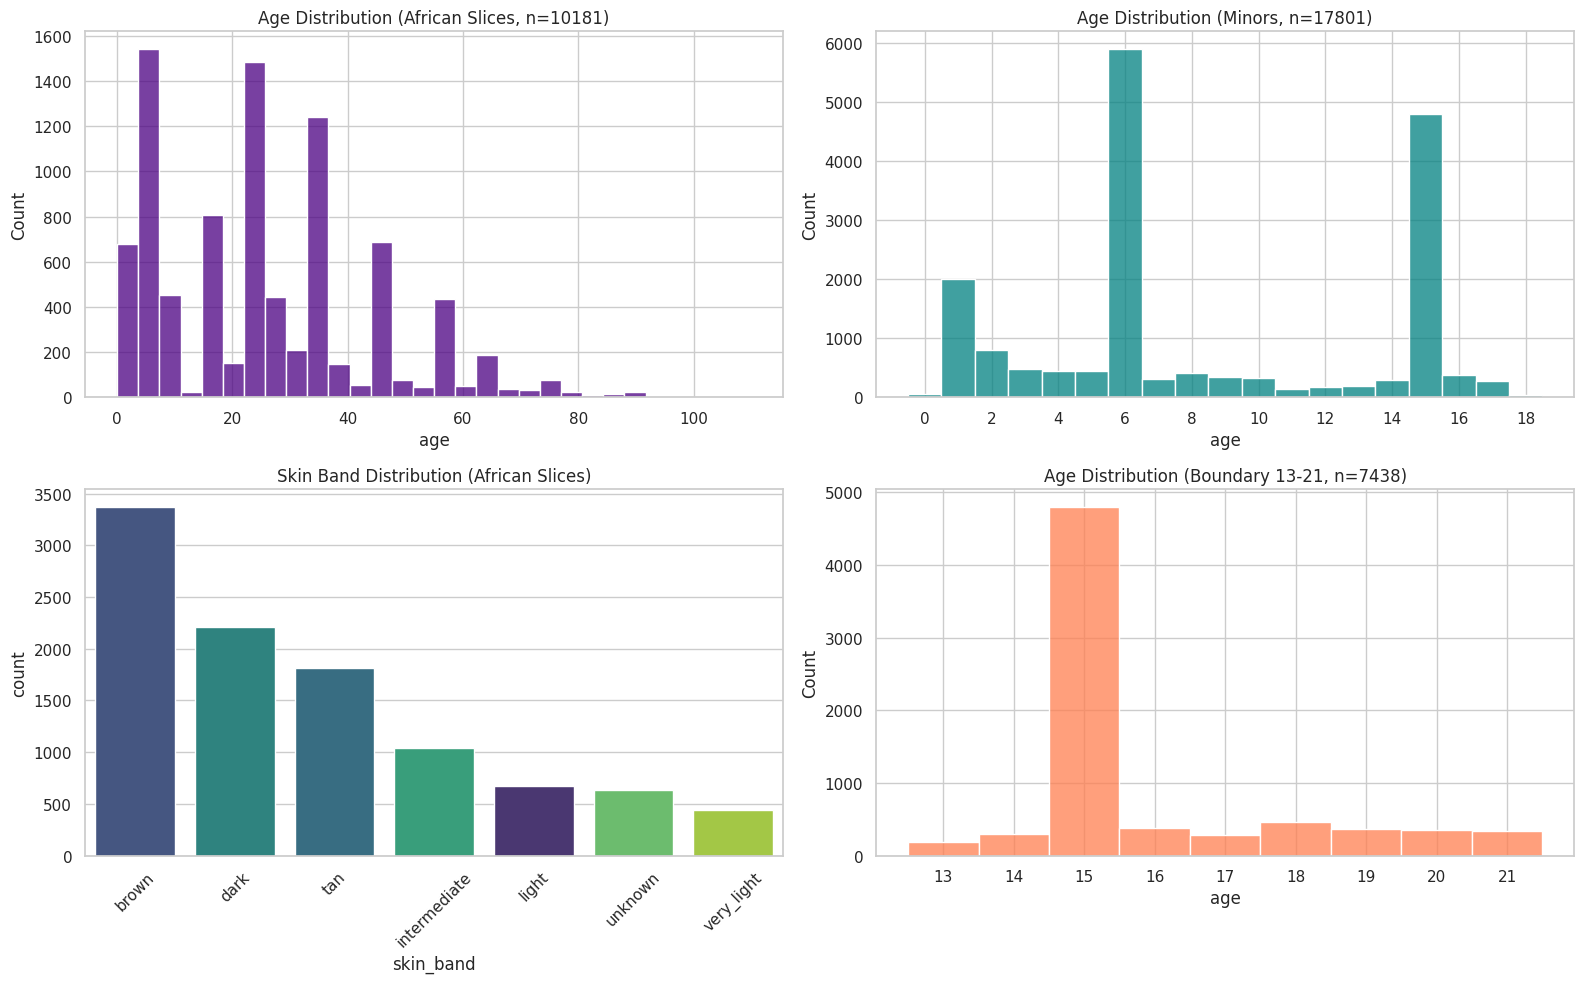

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

if len(public) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))

    # 1. African slices: Age distribution
    african_df = public[african_signal]
    if len(african_df) > 0:
        sns.histplot(african_df['age'].dropna(), bins=30, ax=axes[0, 0], color='indigo')
        axes[0, 0].set_title(f'Age Distribution (African Slices, n={len(african_df)})')

        # 3. African slices: Skin band distribution
        sns.countplot(data=african_df, x='skin_band', hue='skin_band', ax=axes[1, 0], palette='viridis', order=african_df['skin_band'].value_counts().index, legend=False)
        axes[1, 0].set_title('Skin Band Distribution (African Slices)')
        axes[1, 0].tick_params(axis='x', rotation=45)

    # 2. Minors: Age distribution
    minors_df = public[public['is_minor'] == True]
    if len(minors_df) > 0:
        sns.histplot(minors_df['age'].dropna(), bins=18, ax=axes[0, 1], color='teal', discrete=True)
        axes[0, 1].set_title(f'Age Distribution (Minors, n={len(minors_df)})')
        axes[0, 1].set_xticks(range(0, 19, 2))

    # 4. Boundary 13-21: Age distribution
    boundary_df = public[boundary]
    if len(boundary_df) > 0:
        sns.histplot(boundary_df['age'].dropna(), bins=9, ax=axes[1, 1], color='coral', discrete=True)
        axes[1, 1].set_title(f'Age Distribution (Boundary 13-21, n={len(boundary_df)})')
        axes[1, 1].set_xticks(range(13, 22))

    plt.tight_layout()
    plt.show()
else:
    print("No data available to visualize.")

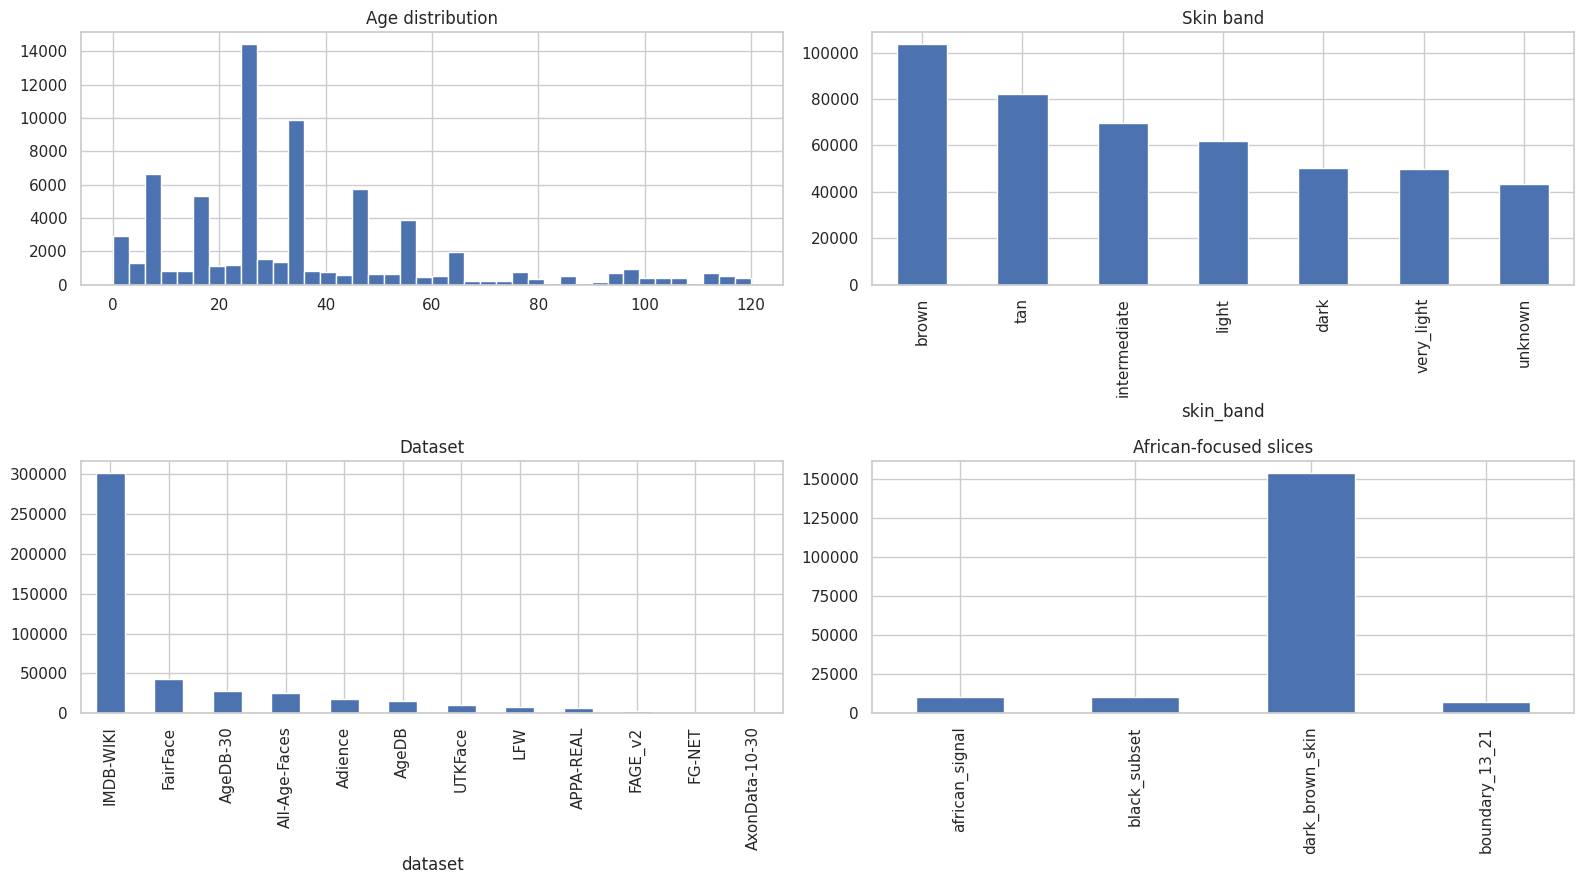

wrote reports: /content/kamari/data/cards/data_quality_report.md /content/kamari/data/cards/AFRICAN_TAILORING_REPORT.md


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')


def _ds_age_audit(frame):
    a = frame.dropna(subset=['age'])
    if not len(a):
        return pd.DataFrame()
    gg = a.groupby('dataset')['age'].agg(n='size', amin='min', amax='max', amean='mean', nunique='nunique')
    gg['pct_u5'] = a.assign(u=a['age'] < 5).groupby('dataset')['u'].mean()
    gg['pct_u13'] = a.assign(u=a['age'] < 13).groupby('dataset')['u'].mean()
    return gg.round(2)


audit_tbl = _ds_age_audit(public)
print('per-dataset age audit (post-clean):\n', audit_tbl.to_string() if len(audit_tbl) else '(no aged rows)')

if len(public):
    fig, ax = plt.subplots(2, 3, figsize=(20, 11))
    public['age'].dropna().hist(bins=40, ax=ax[0, 0]); ax[0, 0].set_title('Age distribution (clean)')
    ax[0, 0].axvspan(13, 21, color='orange', alpha=0.2)
    public['skin_band'].fillna('unknown').value_counts().plot.bar(ax=ax[0, 1], title='Skin band')
    public['dataset'].value_counts().plot.bar(ax=ax[0, 2], title='Rows per dataset')
    tmp = public.dropna(subset=['age']).copy()
    if len(tmp):
        tmp['ab'] = pd.cut(tmp['age'], [0, 12, 17, 20, 25, 35, 50, 120],
                           labels=['0-12', '13-17', '18-20', '21-25', '26-35', '36-50', '51+'])
        sns.heatmap(pd.crosstab(tmp['skin_band'], tmp['ab']), annot=True, fmt='d', cmap='YlGnBu', ax=ax[1, 0])
        ax[1, 0].set_title('skin x age coverage')
    public['gender'].fillna('unknown').value_counts().plot.bar(ax=ax[1, 1], title='Gender')
    public['face_quality'].dropna().hist(bins=30, ax=ax[1, 2]); ax[1, 2].set_title('Face quality')
    plt.tight_layout(); plt.savefig(FIG / 'eda_overview.png', dpi=130); plt.show()
else:
    print('No processed rows yet.')

overlap = set(train['image_id']) & set(bench['image_id'])
print('train/benchmark image overlap:', len(overlap), '(MUST be 0)')

sus = {}
try:
    sus = json.loads((CARDS / 'SUSPECT_DATASETS.json').read_text())
except Exception:
    pass
lines = [
    '# Kámárí Data Quality Report (v0)\n',
    f'- Total rows: {len(public)} | exact-age: {int((public.age_exact==True).sum()) if len(public) else 0} | train_ok: {int((public.train_ok==True).sum()) if len(public) else 0}',
    f'- Minors(<18): {int((public.is_minor==True).sum()) if len(public) else 0} | boundary 13-21: {int(public.age.between(13,21).sum()) if len(public) else 0}',
    f'- Dark/brown skin: {int(public.skin_band.isin(["brown","dark"]).sum()) if len(public) else 0} | African-signal: {int(african_signal.sum()) if len(public) else 0}',
    f'- train rows: {len(train)} | benchmark rows: {len(bench)} | train/bench overlap: {len(overlap)} (must be 0)',
    '\n## Per-dataset age audit (post-clean)\n', (audit_tbl.to_markdown() if len(audit_tbl) else '_none_'),
    '\n## SUSPECT datasets (ages auto-voided)\n', ('\n'.join(f'- {k}: {v}' for k, v in sus.items()) or '_none detected_'),
    '\n## Skin band\n', public['skin_band'].value_counts(dropna=False).to_markdown() if len(public) else '_none_',
    '\n## Datasets\n', public['dataset'].value_counts().to_markdown() if len(public) else '_none_',
]
(CARDS / 'data_quality_report.md').write_text('\n'.join(map(str, lines)))
print('wrote data_quality_report.md + SUSPECT_DATASETS.json')

## 4 · Publish to Hugging Face
Set `PUBLISH_TO_HF=1`, `HF_TOKEN`, and `HF_NAMESPACE` in Colab secrets to publish. Caution: crops are uploaded only to a private repo and only for rows whose licence allows redistribution, unless you explicitly set `ALLOW_PRIVATE_CROP_UPLOAD=1` after confirming rights.

In [7]:
# 4a · kamari-faces-v0 (PRIVATE): licence-safe crops + manifests with paths rewritten to crops/<file>
if not PUBLISH_TO_HF:
    print('PUBLISH_TO_HF is not enabled. Local artifacts are ready under:', DATA_ROOT)
elif not hf:
    raise RuntimeError('Set HF_TOKEN and HF_NAMESPACE before publishing.')
else:
    FACES = 'kamari-faces-v0'
    hf.ensure_repo(FACES, 'dataset', private=True)
    allowed = public['license'].fillna('').str.lower().isin({'cc-by-4.0', 'cc by 4.0', 'cc-by', 'cc by 4.0 with attribution'})
    uploadable = public[allowed | ALLOW_PRIVATE_CROP_UPLOAD].copy()
    tmp = Path(tempfile.mkdtemp()) / 'crops'; tmp.mkdir(parents=True)
    for p in uploadable['path']:
        src = REPO / p if not Path(p).is_absolute() else Path(p)
        if src.exists():
            shutil.copy(src, tmp / src.name)
    uploaded_names = {x.name for x in tmp.glob('*')}
    PACK_CROPS = bool(globals().get('PACK_CROPS', True))
    if len(uploaded_names) and PACK_CROPS:
        # One tar (fast + scales past HF's ~100k-file practicality). train_cnn extracts it.
        tarpath = Path(tempfile.mkdtemp()) / 'crops_v0.tar'
        with tarfile.open(tarpath, 'w') as _tf:
            for _x in tmp.glob('*'):
                _tf.add(_x, arcname=f'crops/{_x.name}')
        hf.upload_file(str(tarpath), FACES, 'crops_v0.tar', repo_type='dataset')
    elif len(uploaded_names):
        hf.upload_folder(str(tmp), FACES, repo_type='dataset', path_in_repo='crops')
    for d, n in [(public, 'public'), (train, 'train'), (bench, 'benchmark')]:
        d2 = d.copy()
        d2['path'] = d2['path'].map(lambda p: f"crops/{Path(p).name}" if Path(p).name in uploaded_names else p)
        hf.push_manifest(d2, FACES, split=n)
    print('faces ->', f'https://huggingface.co/datasets/{hf.repo_id(FACES)}', '| crops uploaded:', len(uploaded_names))

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  .../tmppwy9922l/crops_v0.tar:   0%|          |  586kB / 8.87GB            

Uploading files as a binary IO buffer is not supported by Xet Storage. Falling back to HTTP upload.
Uploading files as a binary IO buffer is not supported by Xet Storage. Falling back to HTTP upload.
Uploading files as a binary IO buffer is not supported by Xet Storage. Falling back to HTTP upload.


faces -> https://huggingface.co/datasets/Shinzmann/kamari-faces-v0 | crops uploaded: 460510


In [8]:
# 4b · provenance (dataset-registry-v0) + frozen benchmark (kamari-safe-open-v0)
if not PUBLISH_TO_HF:
    print('Publishing skipped. Set PUBLISH_TO_HF=1 in Colab secrets to push HF artifacts.')
    print('Local handoff files:')
    for p in [MAN, BENCH_SPLITS, CARDS]:
        print('  ', p)
elif not hf:
    raise RuntimeError('Set HF_TOKEN and HF_NAMESPACE before publishing.')
else:
    DS, BENCH = 'dataset-registry-v0', 'kamari-safe-open-v0'
    for n, d in [('public', public), ('train', train), ('benchmark', bench)]:
        hf.push_manifest(d, DS, split=n)
    for local, rp in [
        (REPO / 'data' / 'registry' / 'datasets_free_open.yaml', 'registry/datasets_free_open.yaml'),
        (REPO / 'data' / 'registry' / 'dataset_sources.yaml', 'registry/dataset_sources.yaml'),
        (REPO / 'data' / 'registry' / 'licenses.md', 'registry/licenses.md'),
        (CARDS / 'download_status.csv', 'reports/download_status.csv'),
        (CARDS / 'adapter_status.csv', 'reports/adapter_status.csv'),
        (CARDS / 'pipeline_dataset_audit.csv', 'reports/pipeline_dataset_audit.csv'),
        (CARDS / 'pipeline_dataset_audit.md', 'reports/pipeline_dataset_audit.md'),
        (CARDS / 'data_quality_report.md', 'reports/data_quality_report.md'),
        (CARDS / 'AFRICAN_TAILORING_REPORT.md', 'reports/AFRICAN_TAILORING_REPORT.md'),
        (CARDS / 'BENCHMARK_CARD.md', 'BENCHMARK_CARD.md'),
        (CARDS / 'manifest_summary.json', 'reports/manifest_summary.json'),
        (CARDS / 'preprocess_failures.json', 'reports/preprocess_failures.json'),
    ]:
        if local.exists():
            hf.upload_file(str(local), DS, rp, repo_type='dataset')
    for png in FIG.glob('*.png'):
        hf.upload_file(str(png), DS, f'reports/eda/{png.name}', repo_type='dataset')
    card = dataset_card(os.environ.get('HF_NAMESPACE', 'kamari'), len(public), sorted(public['dataset'].dropna().unique().tolist()) if len(public) else [])
    (CARDS / 'DATASET_CARD.md').write_text(card)
    hf.upload_file(str(CARDS / 'DATASET_CARD.md'), DS, 'README.md', repo_type='dataset')
    hf.push_manifest(bench, BENCH, split='benchmark')
    for split_file in BENCH_SPLITS.glob('*.parquet'):
        hf.upload_file(str(split_file), BENCH, f'splits/{split_file.name}', repo_type='dataset')
    hf.upload_file(str(CARDS / 'BENCHMARK_CARD.md'), BENCH, 'README.md', repo_type='dataset')

    print('Done. Hugging Face artifacts:')
    for r in ['kamari-faces-v0', DS, BENCH]:
        print('  ', f'https://huggingface.co/datasets/{hf.repo_id(r)}')
    print('\nModal CNN training reads from', hf.repo_id('kamari-faces-v0'))

Uploading files as a binary IO buffer is not supported by Xet Storage. Falling back to HTTP upload.
Uploading files as a binary IO buffer is not supported by Xet Storage. Falling back to HTTP upload.
Uploading files as a binary IO buffer is not supported by Xet Storage. Falling back to HTTP upload.


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...cards/eda/overview_v2.png: 100%|##########|  131kB /  131kB            

Uploading files as a binary IO buffer is not supported by Xet Storage. Falling back to HTTP upload.


...

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...boundary_13_21_v0.parquet:  82%|########2 |  542kB /  660kB            

/usr/local/lib/python3.12/dist-packages/huggingface_hub/hf_api.py:11186: UserWarning: Warnings while validating metadata in README.md:
- empty or missing yaml metadata in repo card
  warnings.warn(f"Warnings while validating metadata in README.md:\n{message}")


Done. Hugging Face artifacts:
   https://huggingface.co/datasets/Shinzmann/kamari-faces-v0
   https://huggingface.co/datasets/Shinzmann/dataset-registry-v0
   https://huggingface.co/datasets/Shinzmann/kamari-safe-open-v0

Modal CNN training reads from Shinzmann/kamari-faces-v0
